# S5 — Primary model (pre-specified)

Primary endpoint: **TG/HDL > cutoff** (`ep_primary`)
Primary exposure: **TAI definition A** (`tai_A`)
Primary model: **Firth logistic regression** with bootstrap confidence intervals for odds ratios.

Because events are sparse in the TAI+ group, standard MLE logistic regression may be unstable.
The primary binary model therefore uses Firth penalized likelihood, consistent with the project config.

Robustness companion analysis:
- Continuous outcome: **log(TG/HDL ratio)** ~ TAI_A + age

Outputs:
- `Table2_primary_model.csv`
- `Table2_primary_model_continuous_companion.csv`
- `primary_model_event_counts.csv`
- forest plot for OR (TAI_A + age)
- calibration summary + calibration curve figure

Important:
- S4 Table 1 cohort and S5 primary model cohort are not expected to be identical.
- S4 describes women with definable exposure (`tai_A`).
- S5 additionally requires a defined primary endpoint (`ep_primary`) and complete covariates.

## Imports

In [ ]:
import json
import logging
from pathlib import Path
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.special import expit
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LinearRegression

## Config

In [ ]:
def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def resolve_config_path() -> Path:
    candidates = [
        Path("/content/reports/config_snapshot.json"),
        Path("/mnt/data/config_snapshot.json"),
        Path("/content/config.json"),
        Path("/mnt/data/config.json"),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "No config found. Expected config_snapshot.json or config.json in /content or /mnt/data."
    )

CONFIG_PATH = resolve_config_path()
CFG = load_json(CONFIG_PATH)

print("Loaded config:", str(CONFIG_PATH))

Loaded config: /content/config.json


## Directories and logging

In [ ]:
def ensure_dirs(cfg: dict) -> None:
    path_keys = [
        "output_dir",
        "intermediate_dir",
        "figures_dir",
        "tables_dir",
        "models_dir",
        "reports_dir",
        "qc_dir",
        "supplementary_dir",
    ]
    for key in path_keys:
        if key in cfg.get("paths", {}):
            Path(cfg["paths"][key]).mkdir(parents=True, exist_ok=True)

def setup_logging(cfg: dict) -> None:
    if not cfg.get("logging", {}).get("enabled", False):
        return

    root_logger = logging.getLogger()
    if root_logger.handlers:
        root_logger.setLevel(logging.INFO)
        return

    log_file = Path(cfg["logging"]["log_file"])
    log_file.parent.mkdir(parents=True, exist_ok=True)

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(message)s",
        handlers=[
            logging.FileHandler(log_file, encoding="utf-8"),
            logging.StreamHandler(),
        ],
    )
    logging.info("Logging initialized in S5.")
    logging.info("Config loaded from: %s", str(CONFIG_PATH))

ensure_dirs(CFG)
setup_logging(CFG)

tables_dir = Path(CFG["paths"]["tables_dir"])
figures_dir = Path(CFG["paths"]["figures_dir"])
models_dir = Path(CFG["paths"]["models_dir"])
reports_dir = Path(CFG["paths"]["reports_dir"])
intermediate_dir = Path(CFG["paths"]["intermediate_dir"])

## Load pcos_analysis

In [ ]:
def resolve_analysis_data_paths(cfg: dict) -> List[Path]:
    return [
        Path(cfg["paths"]["intermediate_dir"]) / "pcos_analysis.parquet",
        Path(cfg["paths"]["intermediate_dir"]) / "pcos_analysis.csv",
        Path("/content/pcos_analysis.parquet"),
        Path("/content/pcos_analysis.csv"),
        Path("/mnt/data/pcos_analysis.parquet"),
        Path("/mnt/data/pcos_analysis.csv"),
    ]

def load_analysis_dataset(cfg: dict) -> Tuple[pd.DataFrame, str]:
    candidates = resolve_analysis_data_paths(cfg)

    parquet_candidates = [p for p in candidates if p.suffix == ".parquet" and p.exists()]
    csv_candidates = [p for p in candidates if p.suffix == ".csv" and p.exists()]

    for p in parquet_candidates:
        try:
            df = pd.read_parquet(p)
            return df, str(p)
        except Exception as e:
            logging.warning("Failed to read parquet %s: %r", str(p), e)

    for p in csv_candidates:
        try:
            df = pd.read_csv(p)
            return df, str(p)
        except Exception as e:
            logging.warning("Failed to read csv %s: %r", str(p), e)

    raise FileNotFoundError(
        "Could not locate pcos_analysis.parquet or pcos_analysis.csv in configured/intermediate locations."
    )

df, source_used = load_analysis_dataset(CFG)

print("Loaded:", source_used)
print("Shape:", df.shape)
df.head(3)

Loaded: /content/pcos_analysis.parquet
Shape: (1300, 77)


,id,age,anti_tpo,anti_tg,tsh,ft4,ft3,tg,hdl,tc,...,analysis_primary_minimal,analysis_non_hdl_minimal,analysis_ogtt120_minimal,exposure_tai_A_defined,endpoint_primary_defined,endpoint_non_hdl_defined,endpoint_ogtt120_defined,analysis_primary_eligible,analysis_non_hdl_eligible,analysis_ogtt120_eligible
0,7611,25.0,13.8,NaN,0.969,1.20,NaN,116.0,56.6,188.0,...,True,True,True,True,True,True,True,True,True,True
1,8133,25.0,12.6,NaN,2.050,1.18,NaN,144.0,41.9,196.0,...,True,True,True,True,True,True,True,True,True,True
2,11028,25.0,150.0,NaN,2.500,1.29,NaN,35.8,62.7,133.0,...,True,True,True,True,True,True,True,True,True,True


## Helpers

In [ ]:
def add_intercept(X: np.ndarray) -> np.ndarray:
    return np.column_stack([np.ones(X.shape[0]), X])


def _safe_expit(z: np.ndarray) -> np.ndarray:
    return np.clip(expit(z), 1e-10, 1 - 1e-10)


def _firth_step_components(X: np.ndarray, y: np.ndarray, beta: np.ndarray):

    eta = X @ beta
    p = _safe_expit(eta)
    W = np.clip(p * (1 - p), 1e-10, None)

    XtWX = X.T @ (W[:, None] * X)
    XtWX_inv = np.linalg.pinv(XtWX)


    quad = np.einsum("ij,jk,ik->i", X, XtWX_inv, X)
    h = np.clip(W * quad, 0.0, 1.0)


    a = h * (0.5 - p)
    U_star = X.T @ (y - p + a)

    return p, W, XtWX, XtWX_inv, h, a, U_star


def fit_firth_logistic(
    X: np.ndarray,
    y: np.ndarray,
    maxiter: int = 200,
    tol: float = 1e-8,
    max_halving: int = 25
) -> Dict[str, Any]:

    beta = np.zeros(X.shape[1], dtype=float)

    def penalized_objective(b: np.ndarray) -> float:
        eta = X @ b
        p = _safe_expit(eta)
        W = np.clip(p * (1 - p), 1e-10, None)
        XtWX = X.T @ (W[:, None] * X)
        sign, logdet = np.linalg.slogdet(XtWX)
        if sign <= 0:
            return np.inf
        loglik = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
        return -(loglik + 0.5 * logdet)

    obj = penalized_objective(beta)
    converged = False
    message = "Maximum iterations reached"

    for it in range(1, maxiter + 1):
        p, W, XtWX, XtWX_inv, h, a, U_star = _firth_step_components(X, y, beta)


        step = XtWX_inv @ U_star


        if np.max(np.abs(U_star)) < tol and np.max(np.abs(step)) < tol:
            converged = True
            message = "Converged"
            break

        beta_candidate = beta + step
        obj_candidate = penalized_objective(beta_candidate)


        halving = 0
        while (not np.isfinite(obj_candidate) or obj_candidate > obj) and halving < max_halving:
            step = step / 2.0
            beta_candidate = beta + step
            obj_candidate = penalized_objective(beta_candidate)
            halving += 1


        if np.isfinite(obj_candidate) and obj_candidate <= obj:
            beta = beta_candidate
            obj = obj_candidate
        else:
            message = "Step-halving failed to improve objective"
            break

        if np.max(np.abs(step)) < tol:
            converged = True
            message = "Converged"
            break


    eta = X @ beta
    p = _safe_expit(eta)
    W = np.clip(p * (1 - p), 1e-10, None)
    XtWX = X.T @ (W[:, None] * X)
    cov = np.linalg.pinv(XtWX)

    return {
        "beta": beta,
        "p": p,
        "cov": cov,
        "converged": bool(converged),
        "message": str(message),
        "n_iter": int(it),
        "objective": float(obj),
        "optimizer": "firth_adjusted_score",
    }


def bootstrap_firth_or_ci(
    X: np.ndarray,
    y: np.ndarray,
    term_names: List[str],
    n_boot: int,
    seed: int
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = len(y)
    boot_betas = []
    n_nonconverged = 0
    n_failed = 0

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Xb = X[idx]
        yb = y[idx]

        if len(np.unique(yb)) < 2:
            n_failed += 1
            continue

        try:
            fit_b = fit_firth_logistic(Xb, yb)
            if not fit_b["converged"]:
                n_nonconverged += 1
            boot_betas.append(fit_b["beta"])
        except Exception:
            n_failed += 1
            continue

    if len(boot_betas) == 0:
        raise RuntimeError("No successful bootstrap fits for Firth model.")

    boot_betas = np.asarray(boot_betas)

    print(
        f"Bootstrap summary: {len(boot_betas)} successful fits, "
        f"{n_nonconverged} not fully converged, {n_failed} failed/skipped."
    )

    rows = []
    for j, term in enumerate(term_names):
        vals = boot_betas[:, j]
        rows.append({
            "term": term,
            "beta_boot_median": float(np.median(vals)),
            "OR_boot_median": float(np.exp(np.median(vals))),
            "CI_low": float(np.exp(np.quantile(vals, 0.025))),
            "CI_high": float(np.exp(np.quantile(vals, 0.975))),
            "n_boot_success": int(len(boot_betas)),
            "n_boot_nonconverged": int(n_nonconverged),
            "n_boot_failed_or_skipped": int(n_failed),
        })
    return pd.DataFrame(rows)

## Definition of the model cohort

In [ ]:
def to_bool01(s: pd.Series) -> pd.Series:
    return s.astype(int)

def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors='coerce')

EXPOSURE = "tai_A"
ENDPOINT = "ep_primary"
COVARS = ["age"]

required_cols = [
    EXPOSURE,
    ENDPOINT,
    "analysis_primary_eligible",
] + COVARS

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise KeyError(f"Missing required columns in pcos_analysis: {missing_required}")

# Primary modeling cohort is narrower than the Table 1 cohort from S4.
# S4 describes all women with definable exposure (tai_A),
# whereas S5 requires definable exposure, definable primary endpoint,
# and complete covariates via explicit eligibility flags from S3.

dfm = df.loc[df["analysis_primary_eligible"] == True].copy()

for c in COVARS:
    dfm = dfm[dfm[c].notna()].copy()

dfm = dfm.reset_index(drop=True)

X = pd.DataFrame({
    "TAI_A": to_bool01(dfm[EXPOSURE]),
    "age": to_num(dfm["age"]),
})


X["age_c"] = X["age"] - X["age"].mean()
X = X[["TAI_A", "age_c"]]

y = to_bool01(dfm[ENDPOINT])

mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].astype(int).reset_index(drop=True)

n = int(len(y))
events = int(y.sum())

events_tai = int(((X["TAI_A"] == 1) & (y == 1)).sum())
n_tai = int((X["TAI_A"] == 1).sum())

events_non = int(((X["TAI_A"] == 0) & (y == 1)).sum())
n_non = int((X["TAI_A"] == 0).sum())

print("Primary cohort size:", n)
print("Events total:", events)
print(f"Events in TAI+: {events_tai}/{n_tai}")
print(f"Events in TAI−: {events_non}/{n_non}")
print("Mean age used for centering:", float(dfm.loc[mask, 'age'].mean()))

Primary cohort size: 1053
Events total: 70
Events in TAI+: 4/84
Events in TAI−: 66/969
Mean age used for centering: 21.441595441595442


## Table event counts

In [ ]:
event_counts = pd.DataFrame([
    {
        "cohort": "primary",
        "n_total": n,
        "n_events_total": events,
        "n_tai_pos": n_tai,
        "n_events_tai_pos": events_tai,
        "pct_events_tai_pos": round(events_tai / n_tai * 100, 2) if n_tai > 0 else np.nan,
        "n_tai_neg": n_non,
        "n_events_tai_neg": events_non,
        "pct_events_tai_neg": round(events_non / n_non * 100, 2) if n_non > 0 else np.nan,
    }
])

event_counts_path = tables_dir / "primary_model_event_counts.csv"
event_counts.to_csv(event_counts_path, index=False)

print("Saved:", event_counts_path)
event_counts

Saved: /content/outputs/tables/primary_model_event_counts.csv


,cohort,n_total,n_events_total,n_tai_pos,n_events_tai_pos,pct_events_tai_pos,n_tai_neg,n_events_tai_neg,pct_events_tai_neg
0,primary,1053,70,84,4,4.76,969,66,6.81


## Fit of the main model: Firth logistic

In [ ]:
RANDOM_SEED = int(CFG["project"]["random_seed"])
N_BOOT = 2000

X_np = X.to_numpy(dtype=float)
y_np = y.to_numpy(dtype=int)

X_design = add_intercept(X_np)
term_names = ["Intercept"] + list(X.columns)

fit = fit_firth_logistic(X_design, y_np)

beta = fit["beta"]
p = fit["p"]
cov = fit["cov"]

print("Firth logistic regression fitted.")
print("Converged:", fit["converged"])
print("Message:", fit["message"])
print("Iterations:", fit["n_iter"])
print("Optimizer:", fit["optimizer"])

for nm, b in zip(term_names, beta):
    print(nm, b)

Firth logistic regression fitted.
Converged: True
Message: Converged
Iterations: 8
Optimizer: firth_adjusted_score
Intercept -2.606149966550031
TAI_A -0.2667885624769379
age_c -0.04988566498189298


## Model metrics

In [ ]:
brier = brier_score_loss(y_np, p)

try:
    auc = roc_auc_score(y_np, p)
except Exception:
    auc = np.nan

print("Brier score:", brier)
print("AUC:", auc)

Brier score: 0.061994144972267184
AUC: 0.5287240226711233


## Bootstrap CI dla OR

In [ ]:
boot = bootstrap_firth_or_ci(
    X=X_design,
    y=y_np,
    term_names=term_names,
    n_boot=N_BOOT,
    seed=RANDOM_SEED,
)

boot

Bootstrap summary: 2000 successful fits, 5 not fully converged, 0 failed/skipped.


,term,beta_boot_median,OR_boot_median,CI_low,CI_high,n_boot_success,n_boot_nonconverged,n_boot_failed_or_skipped
0,Intercept,-2.617831,0.072961,0.055560,0.091901,2000,5,0
1,TAI_A,-0.302441,0.739012,0.210853,1.665816,2000,5,0
2,age_c,-0.052879,0.948495,0.802341,1.128790,2000,5,0


## Main model output table

In [ ]:
rows = []
for j, term in enumerate(term_names):
    beta_hat = float(beta[j])
    or_hat = float(np.exp(beta_hat))

    row = boot.loc[boot["term"] == term].iloc[0].to_dict()
    row.update({
        "beta_hat": beta_hat,
        "OR": or_hat,
        "model": "Primary: Firth logistic (ep_primary ~ TAI_A + age_c)",
        "n": n,
        "events": events,
        "events_tai_pos": events_tai,
        "n_tai_pos": n_tai,
        "events_tai_neg": events_non,
        "n_tai_neg": n_non,
        "brier_score": brier,
        "auc": auc,
        "converged": fit["converged"],
        "optimizer_message": fit["message"],
        "n_iter": fit["n_iter"],
        "optimizer": fit["optimizer"],
        "age_centering_mean": float(dfm.loc[mask, "age"].mean()),
    })
    rows.append(row)

table2 = pd.DataFrame(rows)

out_table2 = tables_dir / "Table2_primary_model.csv"
table2.to_csv(out_table2, index=False)

print("Saved:", out_table2)
table2

Saved: /content/outputs/tables/Table2_primary_model.csv


,term,beta_boot_median,OR_boot_median,CI_low,CI_high,n_boot_success,n_boot_nonconverged,n_boot_failed_or_skipped,beta_hat,OR,...,n_tai_pos,events_tai_neg,n_tai_neg,brier_score,auc,converged,optimizer_message,n_iter,optimizer,age_centering_mean
0,Intercept,-2.617831,0.072961,0.055560,0.091901,2000,5,0,-2.606150,0.073818,...,84,66,969,0.061994,0.528724,True,Converged,8,firth_adjusted_score,21.441595
1,TAI_A,-0.302441,0.739012,0.210853,1.665816,2000,5,0,-0.266789,0.765835,...,84,66,969,0.061994,0.528724,True,Converged,8,firth_adjusted_score,21.441595
2,age_c,-0.052879,0.948495,0.802341,1.128790,2000,5,0,-0.049886,0.951338,...,84,66,969,0.061994,0.528724,True,Converged,8,firth_adjusted_score,21.441595


## Forest plot

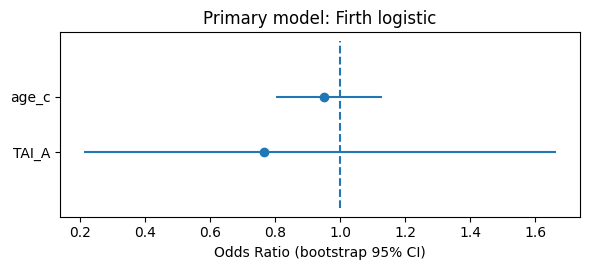

Saved: /content/outputs/figures/F4_forest_OR_primary.png


In [ ]:
plot_df = table2.set_index("term").loc[["TAI_A", "age_c"]].reset_index()

ypos = np.arange(len(plot_df))
or_vals = plot_df["OR"].to_numpy()
lo = plot_df["CI_low"].to_numpy()
hi = plot_df["CI_high"].to_numpy()

plt.figure(figsize=(6, 2.8))
plt.hlines(ypos, lo, hi)
plt.plot(or_vals, ypos, "o")
plt.vlines(1.0, -1, len(ypos), linestyles="dashed")
plt.yticks(ypos, plot_df["term"])
plt.xlabel("Odds Ratio (bootstrap 95% CI)")
plt.title("Primary model: Firth logistic")
plt.tight_layout()

out_forest = figures_dir / "F4_forest_OR_primary.png"
plt.savefig(out_forest, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_forest)

## Calibration curve

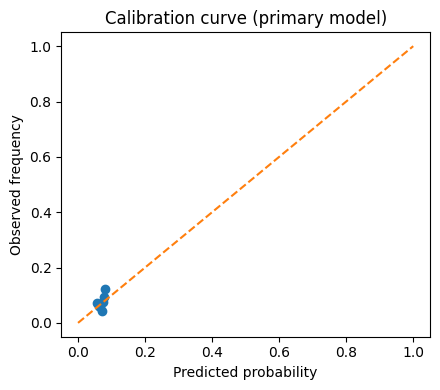

Saved: /content/outputs/figures/F5_calibration_primary.png


In [ ]:
prob_true, prob_pred = calibration_curve(y_np, p, n_bins=8, strategy="quantile")

plt.figure(figsize=(4.5, 4))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration curve (primary model)")
plt.tight_layout()

out_cal = figures_dir / "F5_calibration_primary.png"
plt.savefig(out_cal, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_cal)

## Continuous companion analysis

In [ ]:
# Continuous companion outcome: log(TG/HDL ratio) ~ TAI_A + age_c
dfc = df.copy()

dfc = dfc[dfc[EXPOSURE].notna()].copy()
dfc["tg_hdl_ratio_num"] = to_num(dfc["tg_hdl_ratio"])
dfc["age_num"] = to_num(dfc["age"])
dfc["TAI_A_num"] = to_bool01(dfc[EXPOSURE])

dfc = dfc[
    dfc["tg_hdl_ratio_num"].notna() &
    (dfc["tg_hdl_ratio_num"] > 0) &
    dfc["age_num"].notna() &
    dfc["TAI_A_num"].notna()
].copy()

dfc = dfc.reset_index(drop=True)
dfc["age_c"] = dfc["age_num"] - dfc["age_num"].mean()

yc = np.log(dfc["tg_hdl_ratio_num"])
Xc = pd.DataFrame({
    "TAI_A": dfc["TAI_A_num"],
    "age_c": dfc["age_c"],
})

lin = LinearRegression()
lin.fit(Xc.to_numpy(), yc.to_numpy())

beta_c = lin.coef_.ravel()
inter_c = float(lin.intercept_)
r2_c = float(lin.score(Xc.to_numpy(), yc.to_numpy()))

print("Continuous companion model: log(TG/HDL) ~ TAI_A + age_c")
print("Intercept:", inter_c)
for nm, b in zip(Xc.columns, beta_c):
    print(nm, b)
print("R^2:", r2_c)

comp = pd.DataFrame({
    "term": list(Xc.columns),
    "beta": beta_c,
    "exp_beta": np.exp(beta_c),
    "interpretation": [
        "Multiplicative ratio in TG/HDL for TAI+ vs TAI− after exponentiation",
        "Multiplicative ratio in TG/HDL per 1-year increase in centered age after exponentiation",
    ],
    "model": "Continuous companion: OLS on log(TG/HDL) ~ TAI_A + age_c",
    "n": int(len(Xc)),
    "r_squared": r2_c,
    "age_centering_mean": float(dfc["age_num"].mean()),
})

out_comp = tables_dir / "Table2_primary_model_continuous_companion.csv"
comp.to_csv(out_comp, index=False)

print("Saved:", out_comp)
comp

Continuous companion model: log(TG/HDL) ~ TAI_A + age_c
Intercept: 0.3342415963979337
TAI_A -0.004089568667348839
age_c -0.00468264017872392
R^2: 0.00017821055579836376
Saved: /content/outputs/tables/Table2_primary_model_continuous_companion.csv


,term,beta,exp_beta,interpretation,model,n,r_squared,age_centering_mean
0,TAI_A,-0.004090,0.995919,Multiplicative ratio in TG/HDL for TAI+ vs TAI...,Continuous companion: OLS on log(TG/HDL) ~ TAI...,1053,0.000178,21.441595
1,age_c,-0.004683,0.995328,Multiplicative ratio in TG/HDL per 1-year incr...,Continuous companion: OLS on log(TG/HDL) ~ TAI...,1053,0.000178,21.441595


## Simple JSON summary model record

In [ ]:
summary = {
    "source_used": source_used,
    "primary_model_type": "firth_logistic",
    "exposure": EXPOSURE,
    "endpoint": ENDPOINT,
    "covariates": ["TAI_A", "age_c"],
    "n": n,
    "events": events,
    "events_tai_pos": events_tai,
    "n_tai_pos": n_tai,
    "events_tai_neg": events_non,
    "n_tai_neg": n_non,
    "brier_score": float(brier),
    "auc": float(auc) if pd.notna(auc) else None,
    "converged": bool(fit["converged"]),
    "optimizer_message": fit["message"],
    "n_iter": int(fit["n_iter"]),
    "optimizer": fit["optimizer"],
    "bootstrap_success": int(boot["n_boot_success"].iloc[0]) if len(boot) else 0,
    "bootstrap_nonconverged": int(boot["n_boot_nonconverged"].iloc[0]) if len(boot) else 0,
    "bootstrap_failed_or_skipped": int(boot["n_boot_failed_or_skipped"].iloc[0]) if len(boot) else 0,
    "age_centering_mean": float(dfm.loc[mask, "age"].mean()),
}

summary_path = reports_dir / "s5_primary_model_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved:", summary_path)
summary

Saved: /content/reports/s5_primary_model_summary.json


{'source_used': '/content/pcos_analysis.parquet',
 'primary_model_type': 'firth_logistic',
 'exposure': 'tai_A',
 'endpoint': 'ep_primary',
 'covariates': ['TAI_A', 'age_c'],
 'n': 1053,
 'events': 70,
 'events_tai_pos': 4,
 'n_tai_pos': 84,
 'events_tai_neg': 66,
 'n_tai_neg': 969,
 'brier_score': 0.061994144972267184,
 'auc': 0.5287240226711233,
 'converged': True,
 'optimizer_message': 'Converged',
 'n_iter': 8,
 'optimizer': 'firth_adjusted_score',
 'bootstrap_success': 2000,
 'bootstrap_nonconverged': 5,
 'bootstrap_failed_or_skipped': 0,
 'age_centering_mean': 21.441595441595442}

## Checklist

## S5 completion checklist

- [ ] Review `primary_model_event_counts.csv`.
- [ ] Review `Table2_primary_model.csv`.
- [ ] Confirm OR and 95% CI are reported for `TAI_A` and `age`.
- [ ] Inspect `F4_forest_OR_primary.png`.
- [ ] Inspect `F5_calibration_primary.png`.
- [ ] Review `Table2_primary_model_continuous_companion.csv`.
- [ ] Proceed to S6 (secondary models / sensitivity analyses).